
FFM — Notebook 02: Autoregressive Pre-Training
================================================
Kaggle GPU Notebook

This notebook:
1. Loads tokenized sequences from Phase 1
2. Builds the custom FinancialGPT decoder-only transformer
3. Pre-trains with next-token prediction (causal LM)
4. Uses AMP + gradient checkpointing + torch.compile for speed/memory
5. Saves checkpoints for resumable training

Expected runtime: 6-10 hours on Kaggle T4/P100


# ── Cell 1: Setup ──────────────────────────────────────────────────────────
# %% [markdown]
# # FFM — Phase 2: Autoregressive Pre-Training
# Train FinancialGPT on tokenized multi-asset sequences

In [1]:
import os
import sys
import json
import math
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

# Paths
IS_KAGGLE = os.environ.get("KAGGLE_KERNEL_RUN_TYPE") is not None
if IS_KAGGLE:
    INPUT_DIR = Path("/kaggle/input/notebooks/theophilusmarcus/ffm-phase-1-tokenizer-training")  # Output from notebook 01
    OUTPUT_DIR = Path("/kaggle/working")
else:
    INPUT_DIR = Path("./output")
    OUTPUT_DIR = Path("./output")

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input:  {INPUT_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name()}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ── Cell 2: Model Configuration ───────────────────────────────────────────

Input:  /kaggle/input/notebooks/theophilusmarcus/ffm-phase-1-tokenizer-training
Output: /kaggle/working
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 14.6 GB


In [2]:
# Model hyperparameters
VOCAB_SIZE = 4096
D_MODEL = 256
N_HEADS = 8
N_KV_HEADS = 2
N_LAYERS = 12
D_FF = 896  # SwiGLU: ~3.5x d_model, rounded to 64
CONTEXT_LENGTH = 2048
ROPE_THETA = 10000.0

# Training hyperparameters
LR = 3e-4
MIN_LR = 3e-5
WARMUP_STEPS = 500
MAX_STEPS = 50_000
BATCH_SIZE = 8
GRAD_ACCUM = 8
WEIGHT_DECAY = 0.1
MAX_GRAD_NORM = 1.0
LOG_INTERVAL = 50
SAVE_INTERVAL = 2000

USE_AMP = True
USE_COMPILE = True
USE_GRAD_CHECKPOINT = True

# Estimate param count
embed_params = VOCAB_SIZE * D_MODEL
head_dim = D_MODEL // N_HEADS
attn_per_layer = D_MODEL * (N_HEADS * head_dim + 2 * N_KV_HEADS * head_dim + D_MODEL)
ffn_per_layer = D_MODEL * D_FF * 3
layer_params = attn_per_layer + ffn_per_layer + D_MODEL * 2
total_est = embed_params + N_LAYERS * layer_params
print(f"\nEstimated parameters: {total_est / 1e6:.2f}M")

# ── Cell 3: Model Definition ──────────────────────────────────────────────


Estimated parameters: 11.28M


In [3]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)
        return (x.float() * rms).to(x.dtype) * self.weight


def precompute_rope_freqs(dim, max_seq_len, theta=10000.0):
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
    t = torch.arange(max_seq_len, dtype=torch.float32)
    freqs = torch.outer(t, freqs)
    return torch.polar(torch.ones_like(freqs), freqs)


def apply_rope(x, freqs):
    x_complex = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))
    freqs = freqs[:x.shape[2]].unsqueeze(0).unsqueeze(0)
    x_rotated = x_complex * freqs
    return torch.view_as_real(x_rotated).reshape(*x.shape).to(x.dtype)


class GQAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads, dropout=0.0):
        super().__init__()
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim = d_model // n_heads
        self.n_groups = n_heads // n_kv_heads

        self.q_proj = nn.Linear(d_model, n_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(d_model, n_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(n_heads * self.head_dim, d_model, bias=False)
        self.dropout = dropout

    def forward(self, x, rope_freqs):
        B, T, _ = x.shape
        q = self.q_proj(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_kv_heads, self.head_dim).transpose(1, 2)

        q = apply_rope(q, rope_freqs)
        k = apply_rope(k, rope_freqs)

        if self.n_groups > 1:
            k = k.repeat_interleave(self.n_groups, dim=1)
            v = v.repeat_interleave(self.n_groups, dim=1)

        attn_out = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=True)

        return self.o_proj(attn_out.transpose(1, 2).contiguous().view(B, T, -1))


class SwiGLUFFN(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.gate_proj = nn.Linear(d_model, d_ff, bias=False)
        self.up_proj = nn.Linear(d_model, d_ff, bias=False)
        self.down_proj = nn.Linear(d_ff, d_model, bias=False)

    def forward(self, x):
        return self.down_proj(F.silu(self.gate_proj(x)) * self.up_proj(x))


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, n_kv_heads, d_ff, dropout=0.0):
        super().__init__()
        self.attn_norm = RMSNorm(d_model)
        self.attn = GQAttention(d_model, n_heads, n_kv_heads, dropout)
        self.ffn_norm = RMSNorm(d_model)
        self.ffn = SwiGLUFFN(d_model, d_ff)

    def forward(self, x, rope_freqs):
        x = x + self.attn(self.attn_norm(x), rope_freqs)
        x = x + self.ffn(self.ffn_norm(x))
        return x


class FinancialGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_kv_heads, n_layers, d_ff,
                 context_length, rope_theta=10000.0, use_grad_checkpoint=False):
        super().__init__()
        self.vocab_size = vocab_size
        self.context_length = context_length
        self.use_grad_checkpoint = use_grad_checkpoint

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, n_heads, n_kv_heads, d_ff)
            for _ in range(n_layers)
        ])
        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_emb.weight  # Weight tying

        head_dim = d_model // n_heads
        self.register_buffer("rope_freqs",
            precompute_rope_freqs(head_dim, context_length * 2, rope_theta),
            persistent=False)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, token_ids, targets=None):
        B, T = token_ids.shape
        x = self.token_emb(token_ids)

        for layer in self.layers:
            if self.use_grad_checkpoint and self.training:
                x = torch.utils.checkpoint.checkpoint(layer, x, self.rope_freqs, use_reentrant=False)
            else:
                x = layer(x, self.rope_freqs)

        x = self.final_norm(x)
        logits = self.lm_head(x)

        result = {"logits": logits}
        if targets is not None:
            result["loss"] = F.cross_entropy(logits.view(-1, self.vocab_size), targets.view(-1), ignore_index=-1)
        return result

    @torch.no_grad()
    def generate(self, prompt, max_new_tokens=128, temperature=1.0, top_k=50):
        self.eval()
        generated = prompt.clone()
        for _ in range(max_new_tokens):
            context = generated[:, -self.context_length:]
            logits = self(context)["logits"][:, -1, :] / temperature
            if top_k > 0:
                topk_vals, _ = logits.topk(top_k)
                logits = logits.masked_fill(logits < topk_vals[:, -1:], float("-inf"))
            next_tok = torch.multinomial(F.softmax(logits, dim=-1), 1)
            generated = torch.cat([generated, next_tok], dim=1)
        return generated


# Build model
model = FinancialGPT(
    VOCAB_SIZE, D_MODEL, N_HEADS, N_KV_HEADS, N_LAYERS, D_FF,
    CONTEXT_LENGTH, ROPE_THETA, USE_GRAD_CHECKPOINT,
)
total_params = sum(p.numel() for p in model.parameters())
print(f"FinancialGPT: {total_params:,} parameters ({total_params/1e6:.2f}M)")

# ── Cell 4: Dataset ───────────────────────────────────────────────────────

FinancialGPT: 11,278,592 parameters (11.28M)


In [4]:
class TokenSequenceDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        return (torch.from_numpy(seq[:-1].astype(np.int64)),
                torch.from_numpy(seq[1:].astype(np.int64)))


# Load sequences
seq_path = INPUT_DIR / "token_sequences.npy"
sequences = np.load(seq_path)
print(f"Loaded {sequences.shape[0]:,} sequences of length {sequences.shape[1]}")

dataset = TokenSequenceDataset(sequences)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=2, pin_memory=True, drop_last=True)

steps_per_epoch = len(loader) // GRAD_ACCUM
# Adjust max_steps if dataset is smaller
actual_max_steps = min(MAX_STEPS, steps_per_epoch * 20)  # Cap at 20 epochs
print(f"Steps/epoch: {steps_per_epoch}, max_steps: {actual_max_steps}")

# ── Cell 5: Training Setup ────────────────────────────────────────────────

Loaded 3,717 sequences of length 2049
Steps/epoch: 58, max_steps: 1160


In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

if USE_COMPILE and device == "cuda":
    print("Compiling model...")
    model = torch.compile(model)

# Optimizer with weight decay separation
decay_params = [p for n, p in model.named_parameters() if p.requires_grad and "norm" not in n and "bias" not in n]
no_decay_params = [p for n, p in model.named_parameters() if p.requires_grad and ("norm" in n or "bias" in n)]

optimizer = torch.optim.AdamW([
    {"params": decay_params, "weight_decay": WEIGHT_DECAY},
    {"params": no_decay_params, "weight_decay": 0.0},
], lr=LR, betas=(0.9, 0.95), fused=(device == "cuda"))

# AMP
amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and amp_dtype == torch.float16))
print(f"AMP dtype: {amp_dtype}")


def get_lr(step):
    if step < WARMUP_STEPS:
        return LR * (step + 1) / WARMUP_STEPS
    if step >= actual_max_steps:
        return MIN_LR
    progress = (step - WARMUP_STEPS) / (actual_max_steps - WARMUP_STEPS)
    return MIN_LR + 0.5 * (LR - MIN_LR) * (1 + math.cos(math.pi * progress))


# Check for resume checkpoint
resume_step = 0
resume_path = CHECKPOINT_DIR / "pretrain_latest.pt"
if resume_path.exists():
    print(f"Resuming from {resume_path}...")
    ckpt = torch.load(resume_path, map_location=device, weights_only=False)
    if hasattr(model, "_orig_mod"):
        model._orig_mod.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    resume_step = ckpt.get("step", 0)
    print(f"Resumed at step {resume_step}")

# ── Cell 6: Pre-Training Loop ─────────────────────────────────────────────

Compiling model...
AMP dtype: torch.bfloat16


In [6]:
print("\n" + "=" * 70)
print(f"Starting pre-training from step {resume_step} to {actual_max_steps}")
print("=" * 70)

model.train()
global_step = resume_step
best_loss = float("inf")
log_history = []
running_loss = 0.0
running_count = 0
t0 = time.time()
data_iter = iter(loader)

while global_step < actual_max_steps:
    try:
        input_ids, target_ids = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        input_ids, target_ids = next(data_iter)

    input_ids = input_ids.to(device, non_blocking=True)
    target_ids = target_ids.to(device, non_blocking=True)

    with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=amp_dtype):
        result = model(input_ids, targets=target_ids)
        loss = result["loss"] / GRAD_ACCUM

    scaler.scale(loss).backward()
    running_loss += result["loss"].item()
    running_count += 1

    if (global_step + 1) % GRAD_ACCUM == 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        lr = get_lr(global_step)
        for pg in optimizer.param_groups:
            pg["lr"] = lr

    global_step += 1

    # Logging
    if global_step % LOG_INTERVAL == 0:
        avg_loss = running_loss / running_count
        elapsed = time.time() - t0
        tps = running_count * BATCH_SIZE * CONTEXT_LENGTH / elapsed

        log_history.append({
            "step": global_step, "loss": avg_loss, "lr": lr, "tps": tps
        })
        print(f"  Step {global_step:6d}/{actual_max_steps} | "
              f"Loss: {avg_loss:.4f} | LR: {lr:.2e} | "
              f"Tok/s: {tps:,.0f} | {elapsed/60:.1f}min")

        running_loss = 0.0
        running_count = 0
        t0 = time.time()

    # Save checkpoint
    if global_step % SAVE_INTERVAL == 0:
        state = model._orig_mod.state_dict() if hasattr(model, "_orig_mod") else model.state_dict()
        ckpt = {
            "step": global_step,
            "model_state_dict": state,
            "optimizer_state_dict": optimizer.state_dict(),
        }
        torch.save(ckpt, CHECKPOINT_DIR / f"pretrain_step_{global_step}.pt")
        torch.save(ckpt, CHECKPOINT_DIR / "pretrain_latest.pt")

        if log_history and log_history[-1]["loss"] < best_loss:
            best_loss = log_history[-1]["loss"]
            torch.save(ckpt, CHECKPOINT_DIR / "pretrain_best.pt")

        print(f"  → Checkpoint saved (step {global_step})")

# Final save
state = model._orig_mod.state_dict() if hasattr(model, "_orig_mod") else model.state_dict()
torch.save({"step": global_step, "model_state_dict": state},
           CHECKPOINT_DIR / "pretrain_final.pt")

with open(OUTPUT_DIR / "pretrain_history.json", "w") as f:
    json.dump(log_history, f, indent=2)

# ── Cell 7: Training Curves ───────────────────────────────────────────────


Starting pre-training from step 0 to 1160


/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:2156: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
W0813 11:42:59.436000 23 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


  Step     50/1160 | Loss: 8.2646 | LR: 2.88e-05 | Tok/s: 4,989 | 2.7min
  Step    100/1160 | Loss: 8.1424 | LR: 5.76e-05 | Tok/s: 5,640 | 2.4min
  Step    150/1160 | Loss: 8.0234 | LR: 8.64e-05 | Tok/s: 5,651 | 2.4min
  Step    200/1160 | Loss: 7.8920 | LR: 1.20e-04 | Tok/s: 5,650 | 2.4min
  Step    250/1160 | Loss: 7.7271 | LR: 1.49e-04 | Tok/s: 5,646 | 2.4min
  Step    300/1160 | Loss: 7.5326 | LR: 1.78e-04 | Tok/s: 5,650 | 2.4min
  Step    350/1160 | Loss: 7.3437 | LR: 2.06e-04 | Tok/s: 5,651 | 2.4min
  Step    400/1160 | Loss: 7.1565 | LR: 2.40e-04 | Tok/s: 5,651 | 2.4min
  Step    450/1160 | Loss: 7.0511 | LR: 2.69e-04 | Tok/s: 5,649 | 2.4min
  Step    500/1160 | Loss: 6.9003 | LR: 2.98e-04 | Tok/s: 5,645 | 2.4min
  Step    550/1160 | Loss: 6.7676 | LR: 2.97e-04 | Tok/s: 5,649 | 2.4min
  Step    600/1160 | Loss: 6.6702 | LR: 2.85e-04 | Tok/s: 5,648 | 2.4min
  Step    650/1160 | Loss: 6.4927 | LR: 2.68e-04 | Tok/s: 5,643 | 2.4min
  Step    700/1160 | Loss: 6.3803 | LR: 2.46e-04 | 

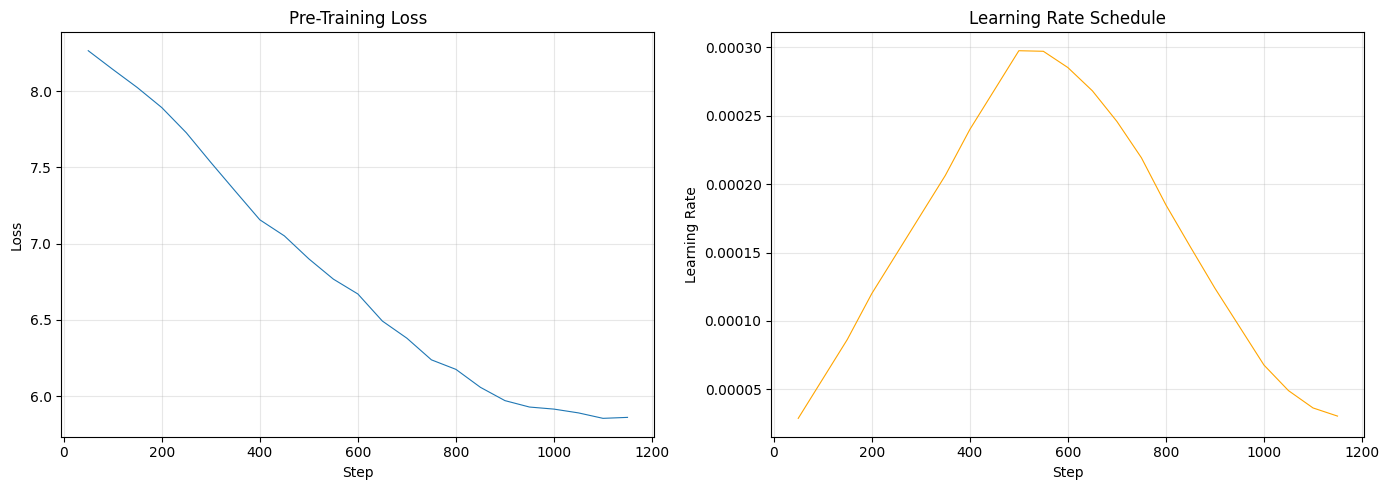

In [7]:
if log_history:
    steps = [h["step"] for h in log_history]
    losses = [h["loss"] for h in log_history]
    lrs = [h["lr"] for h in log_history]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(steps, losses, linewidth=0.8)
    ax1.set_xlabel("Step")
    ax1.set_ylabel("Loss")
    ax1.set_title("Pre-Training Loss")
    ax1.grid(True, alpha=0.3)

    ax2.plot(steps, lrs, linewidth=0.8, color="orange")
    ax2.set_xlabel("Step")
    ax2.set_ylabel("Learning Rate")
    ax2.set_title("Learning Rate Schedule")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "pretrain_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

# ── Cell 8: Generation Test ───────────────────────────────────────────────

In [8]:
# Quick sanity check: generate from a short prompt
if hasattr(model, "_orig_mod"):
    gen_model = model._orig_mod
else:
    gen_model = model

gen_model.eval()
prompt = torch.randint(0, VOCAB_SIZE, (1, 32)).to(device)
generated = gen_model.generate(prompt, max_new_tokens=64, temperature=0.8, top_k=50)
print(f"Prompt:    {prompt[0].tolist()[:10]}...")
print(f"Generated: {generated[0, 32:42].tolist()}...")
print(f"Full length: {generated.shape[1]} tokens")

print("\n" + "=" * 60)
print("PHASE 2 COMPLETE")
print(f"  Final loss: {log_history[-1]['loss']:.4f}" if log_history else "  No training history")
print(f"  Best loss:  {best_loss:.4f}")
print(f"  Steps:      {global_step}")
print("=" * 60)

Prompt:    [1614, 3815, 1948, 663, 2476, 537, 1360, 3456, 2668, 1340]...
Generated: [928, 1000, 751, 876, 748, 620, 750, 1007, 748, 868]...
Full length: 96 tokens

PHASE 2 COMPLETE
  Final loss: 5.8614
  Best loss:  inf
  Steps:      1160
